In [1]:
import torch
from albumentations.pytorch import ToTensorV2
from PIL import Image
import glob
import os
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
import random
import torchvision.transforms.functional as F
from torchvision import transforms as T

d:\coding\python_projects\pytorch\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
dataset_path = os.path.join("dataset")

In [3]:
real_img_path = os.path.join("dataset", "original")
mask_img_path = os.path.join("dataset", "mask")

In [4]:
real_image_files = glob.glob(os.path.join(real_img_path, "*.jpg"))
mask_image_files = glob.glob(os.path.join(mask_img_path, "*.png"))

In [18]:
import random

class BgRemovalDataset(Dataset):
    def __init__(self, real_img_path, mask_img_path, crop_size=512):
        self.real_images = sorted(glob.glob(os.path.join(real_img_path, "*.jpg")))
        self.mask_images = sorted(glob.glob(os.path.join(mask_img_path, "*.png")))
        self.crop_size = crop_size
        self.to_tensor = T.ToTensor()

        assert len(self.real_images) == len(self.mask_images), \
            "Mismatch between images and masks!"

    def __len__(self):
        return len(self.real_images)

    def random_crop(self, image, mask):
        w, h = image.size
        th, tw = self.crop_size, self.crop_size

        if w < tw or h < th:
            new_h = max(h, th)
            new_w = max(w, tw)

            image = F.resize(image, (new_h, new_w))
            mask = F.resize(mask, (new_h, new_w),
                            interpolation=F.InterpolationMode.NEAREST)

            w, h = image.size

        i = random.randint(0, h - th)
        j = random.randint(0, w - tw)

        image = F.crop(image, i, j, th, tw)
        mask = F.crop(mask, i, j, th, tw)

        return image, mask

    def __getitem__(self, idx):
        image = Image.open(self.real_images[idx]).convert("RGB")
        mask = Image.open(self.mask_images[idx]).convert("L")

        image, mask = self.random_crop(image, mask)

        # Optional augmentation
        if random.random() > 0.5:
            image = F.hflip(image)
            mask = F.hflip(mask)

        image = self.to_tensor(image)
        mask = self.to_tensor(mask)

        return image, mask

In [19]:
dataset = BgRemovalDataset(
    real_img_path="dataset/original",
    mask_img_path="dataset/mask",
    crop_size=512
)

loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True
)

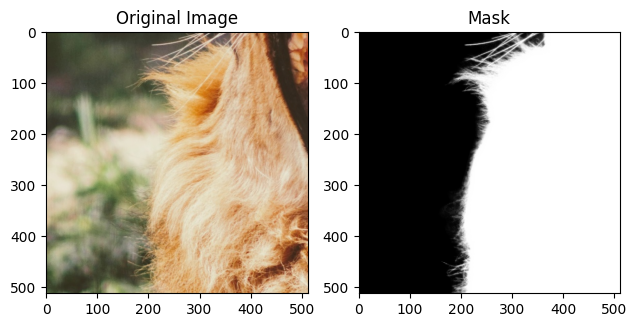

In [56]:
loader_iter = iter(loader)
images, masks = next(loader_iter)

plt.subplot(1, 2, 1)
plt.imshow(images[0].permute(1, 2, 0))
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(masks[0].squeeze(), cmap="gray")
plt.title("Mask")

plt.tight_layout()
plt.show()

In [57]:
from torch import nn

In [58]:
class conv_block(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        # First convolution
        self.conv1 = nn.Conv2d(in_c, out_c, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_c) # Normalize for stable training
        
        # Second convolution
        self.conv2 = nn.Conv2d(out_c, out_c, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_c)
        
      # Non-linear activation
        self.relu = nn.ReLU()

    def forward(self, inputs):
        x = self.conv1(inputs)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)

        return x

In [59]:
class encoder_block(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = conv_block(in_c, out_c)   # Learn features
        self.pool = nn.MaxPool2d((2, 2))

    def forward(self, inputs):
        x = self.conv(inputs)  # Feature map
        p = self.pool(x)       # Downsampled map
        return x, p

In [60]:
class decoder_block(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        # Upsampling: doubles height & width
        self.up = nn.ConvTranspose2d(in_c, out_c, kernel_size=2, stride=2)
        
        # conv_block gets input = upsampled + skip features
        self.conv = conv_block(out_c + out_c, out_c)

    def forward(self, inputs, skip):
        x = self.up(inputs)            # Upsample
        x = torch.cat([x, skip], dim=1)  # Add skip connection
        x = self.conv(x)                # Learn details
        return x

In [63]:
class Unet(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Encoder: shrinking image, increasing channels
        self.e1 = encoder_block(3, 64)
        self.e2 = encoder_block(64, 128)
        self.e3 = encoder_block(128, 256)
        self.e4 = encoder_block(256, 512)
        
        # Bottleneck: middle of the U
        self.b = conv_block(512, 1024)

        # Decoder: growing image back, using skip connections
        self.d1 = decoder_block(1024, 512)
        self.d2 = decoder_block(512, 256)
        self.d3 = decoder_block(256, 128)
        self.d4 = decoder_block(128, 64)
        
        # Final classifier: 1 output channel for binary segmentation
        self.output = nn.Conv2d(64, 1, kernel_size=1)  # 1 channel mask

    def forward(self, inputs):

        # Encoder
        s1, p1 = self.e1(inputs)
        s2, p2 = self.e2(p1)
        s3, p3 = self.e3(p2)
        s4, p4 = self.e4(p3)

        # Bottleneck
        b = self.b(p4)

        # Decoder
        d1 = self.d1(b, s4)
        d2 = self.d2(d1, s3)
        d3 = self.d3(d2, s2)
        d4 = self.d4(d3, s1)

        # Final prediction
        outputs = self.output(d4)
        return outputs

In [64]:
inputs = torch.randn((1, 3, 512, 512))
model = Unet()
outputs = model(inputs)
print(outputs.shape)

torch.Size([1, 1, 512, 512])


In [97]:
image = Image.open("dataset\\original\\o_0b376f13.jpg").convert("RGB")
mask = Image.open("dataset\\mask\\o_0b376f13.png").convert("L")

In [ ]:
import numpy as np

img_np = np.array(image.resize((512, 512)))
img_np.shape

(512, 512, 3)

In [109]:
org_img = np.array(image)

original_size = org_img.shape[:2]
original_size

(1612, 1080)

In [90]:
img = torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0).float() / 255.0
img.shape

torch.Size([1, 3, 512, 512])

In [ ]:
model.eval()
with torch.no_grad():
    out = model(img)

print(out.shape)

torch.Size([1, 1, 512, 512])


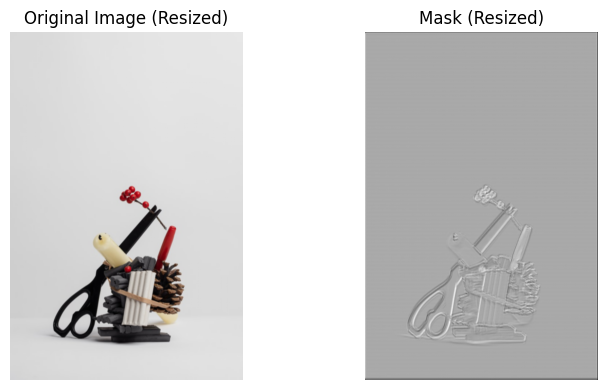

In [111]:
import torchvision.transforms.functional as TF
import torchvision.transforms as T
import matplotlib.pyplot as plt

# Resize image
resized_img = TF.resize(
    img[0], 
    size=original_size, 
    interpolation=T.InterpolationMode.BILINEAR
)

# Resize mask
resized_mask = TF.resize(
    out[0], 
    size=original_size,
    interpolation=T.InterpolationMode.BILINEAR
)

plt.figure(figsize=(8,4))

plt.subplot(1, 2, 1)
plt.imshow(resized_img.permute(1, 2, 0).cpu())
plt.title("Original Image (Resized)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(resized_mask.squeeze().cpu(), cmap="gray")
plt.title("Mask (Resized)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
real_images = sorted(glob.glob(os.path.join(real_img_path, "*.jpg")))
mask_images = sorted(glob.glob(os.path.join(mask_img_path, "*.png")))

In [5]:
len(real_images) == len(mask_images)

True